# Contextual Chatbot with Multi-turn Dialogue Understanding

Fine-tuning **DialoGPT-small** on the **MultiWOZ 2.2** dataset to build a task-oriented
chatbot that maintains context across multiple conversational turns.

---

## Problem

A single-turn chatbot treats every message independently. In a real booking conversation,
most turns only make sense in context:

> **User:** I'm looking for an expensive restaurant in the centre
> **User:** What is *its* phone number?
> **User:** Can you book *it* for 2 people?

Turns 2 and 3 contain no explicit entity — *"its"* and *"it"* refer back to the restaurant
established in turn 1. Resolving these references is the core challenge this project addresses.

## Approach

| Component | Choice |
|---|---|
| Dataset | MultiWOZ 2.2 (8,437 multi-domain task-oriented dialogues) |
| Base model | `microsoft/DialoGPT-small` (117M parameters) |
| Task framing | Causal LM over `(dialogue context → system response)` pairs |
| Context window | Last 4 turns |
| Loss masking | Computed on the response tokens only |

## Results

| Metric | Value |
|---|---|
| Validation loss | 1.91 |
| Perplexity | **6.73** (down from ~271 before fine-tuning) |
| BLEU-4 | 5.19 (150 test samples) |

## 1. Environment Setup

> **Note on pinned versions.** The Kaggle image ships `transformers==5.0.0`, which does not
> preserve GPT-2's **weight tying** between the input embeddings and the `lm_head`
> (it emits `"we will NOT tie them"` on load). Training then diverges to `NaN` within a
> single optimizer step. Pinning `transformers==4.44.2` restores the correct architecture.
>
> **A kernel restart is required after this cell** — Python caches imported modules in memory,
> so a newly installed version is not picked up until the interpreter restarts.

In [ ]:
!pip install -q "transformers==4.44.2" "datasets==2.19.1" "accelerate==0.33.0" "tokenizers<0.20"
print("Installed. Restart the kernel before running the next cell.")

## 2. Load Dataset and Base Model

MultiWOZ 2.2 contains 8,437 training dialogues spanning restaurant, hotel, train, taxi,
attraction, and hospital domains.

`CUDA_VISIBLE_DEVICES` is restricted to a single GPU: Kaggle's T4 ×2 setup triggers
`DataParallel` inside `Trainer`, which adds instability with no throughput benefit for a
model this small.

In [11]:
import transformers
assert transformers.__version__ == "4.44.2", (
    f"Expected transformers 4.44.2, got {transformers.__version__}. "
    "GPT-2 weight tying breaks in v5 and training diverges to NaN."
)
print("Version check passed:", transformers.__version__)

Version check passed: 4.44.2


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch, random, numpy as np
import transformers
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer

print("transformers:", transformers.__version__)    # expected: 4.44.2
print("GPUs visible:", torch.cuda.device_count())

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

raw = load_dataset("multi_woz_v22", trust_remote_code=True)

model_name = "microsoft/DialoGPT-small"
tok = AutoTokenizer.from_pretrained(model_name)
tok.pad_token = tok.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name)

model.config.pad_token_id = tok.eos_token_id
EOS = tok.eos_token_id
print("Loaded ✅")

transformers: 4.44.2
GPUs visible: 1
Loaded ✅


## 3. Building Context → Response Pairs

This is the step that makes the model *contextual* rather than a generic language model.

**Naive approach:** concatenate an entire dialogue into one sequence and train on all tokens.
The model then learns to imitate *both* speakers, with no notion of who it should be.

**This approach:** for every system turn, emit one training example:

    input  = [last 4 turns] <|endoftext|> [system response] <|endoftext|>
    labels = [   -100 ...  ]              [system response] <|endoftext|>

Two design decisions:

1. **Loss masking.** Context tokens are labelled `-100`, which PyTorch's cross-entropy ignores.
   The gradient therefore only reflects how well the model produces the *response* — it learns
   to reply, not to paraphrase the user.

2. **Context window of 4 turns.** Wide enough to resolve most anaphoric references
   (*"its"*, *"it"*), narrow enough to keep sequences short and training fast.

Yield: 1,500 dialogues → **10,196** training pairs.

In [2]:
MAX_CTX_TURNS = 4
MAX_LEN       = 256

def build_pairs(split, n_dialogs=None):
    ds = raw[split]
    if n_dialogs:
        ds = ds.select(range(min(n_dialogs, len(ds))))
    pairs = []
    for d in ds:
        utts = d["turns"]["utterance"]
        spks = d["turns"]["speaker"]
        for i, s in enumerate(spks):
            if s != 1:
                continue
            resp = utts[i].strip()
            if not resp:
                continue
            ctx = [u.strip() for u in utts[max(0, i - MAX_CTX_TURNS):i] if u.strip()]
            if not ctx:
                continue
            pairs.append({"context": ctx, "response": resp})
    return pairs

def encode(p):
    ctx_ids = []
    for u in p["context"]:
        ctx_ids += tok.encode(u) + [EOS]
    resp_ids = tok.encode(p["response"])[: MAX_LEN // 2] + [EOS]

    keep = MAX_LEN - len(resp_ids)
    ctx_ids = ctx_ids[-keep:] if keep > 0 else []

    input_ids = ctx_ids + resp_ids
    labels    = [-100] * len(ctx_ids) + resp_ids
    return {"input_ids": input_ids,
            "labels": labels,
            "attention_mask": [1] * len(input_ids)}

train_data = [encode(p) for p in build_pairs("train", 1500)]
eval_data  = [encode(p) for p in build_pairs("validation", 200)]

train_data = [x for x in train_data if any(l != -100 for l in x["labels"])]
eval_data  = [x for x in eval_data  if any(l != -100 for l in x["labels"])]

print("train:", len(train_data), "| eval:", len(eval_data))
print("\nSample:\n", tok.decode(train_data[0]["input_ids"]))

train: 10196 | eval: 1481

مثال:
 i need a place to dine in the center thats expensive<|endoftext|>I have several options for you; do you prefer African, Asian, or British food?<|endoftext|>


## 4. Collator and Pre-training Sanity Check

Sequences are padded per batch, with padding positions set to `-100` in the labels and `0`
in the attention mask so they contribute nothing to the loss.

The assertion below is a deliberate guard rather than a debug leftover: a healthy
pre-fine-tuning cross-entropy for GPT-2 falls roughly between 3 and 10. A `NaN` here would
indicate malformed labels — for example, an example where *every* label is `-100`, which makes
cross-entropy undefined.

In [3]:
def collate(batch):
    m = max(len(b["input_ids"]) for b in batch)
    ii, ll, aa = [], [], []
    for b in batch:
        pad = m - len(b["input_ids"])
        ii.append(b["input_ids"]      + [EOS]  * pad)
        ll.append(b["labels"]         + [-100] * pad)
        aa.append(b["attention_mask"] + [0]    * pad)
    return {"input_ids": torch.tensor(ii),
            "labels": torch.tensor(ll),
            "attention_mask": torch.tensor(aa)}

model.eval()
with torch.no_grad():
    loss = model(**collate(train_data[:4])).loss
print("sanity loss:", loss.item())
assert torch.isfinite(loss), "Loss is not finite — check label construction before training."

sanity loss: 5.604153633117676


In [4]:
args = TrainingArguments(
    output_dir="./dialogpt_multiwoz",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=4,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    learning_rate=3e-5,
    warmup_steps=50,
    max_grad_norm=1.0,
    weight_decay=0.01,
    fp16=False,
    logging_steps=25,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(model=model, args=args,
                  train_dataset=train_data, eval_dataset=eval_data,
                  data_collator=collate)

trainer.train()

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
0,2.228700,2.054665
1,2.020200,1.934221
2,1.943200,1.906466


There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=1911, training_loss=2.242304800443784, metrics={'train_runtime': 1129.4829, 'train_samples_per_second': 27.081, 'train_steps_per_second': 1.692, 'total_flos': 1723365886464000.0, 'train_loss': 2.242304800443784, 'epoch': 2.9988230678697527})

## 5. Fine-tuning

| Hyperparameter | Value | Rationale |
|---|---|---|
| Epochs | 3 | Validation loss had not yet plateaued |
| Effective batch size | 16 | 4 × 4 gradient accumulation |
| Learning rate | 3e-5 | Conservative, standard for GPT-2 fine-tuning |
| Warmup steps | 50 | Stabilises the initial updates |
| Max grad norm | 1.0 | Gradient clipping |
| fp16 | Disabled | Mixed precision is a known source of `NaN` with GPT-2 |

In [5]:
bad = [n for n, p in model.named_parameters() if not torch.isfinite(p).all()]
print("NaN params:", bad[:3] if bad else "none ✅")

model.eval()

def chat(user_text, history):
    history = history + [user_text]
    ctx = history[-2 * MAX_CTX_TURNS:]
    text = "".join(u + tok.eos_token for u in ctx)
    enc = tok(text, return_tensors="pt", truncation=True, max_length=200).to(model.device)
    with torch.no_grad():
        out = model.generate(
            **enc, max_new_tokens=60,
            pad_token_id=EOS, eos_token_id=EOS,
            do_sample=True, top_p=0.9, top_k=50, temperature=0.8,
            repetition_penalty=1.1, no_repeat_ngram_size=3,
        )
    resp = tok.decode(out[0, enc["input_ids"].shape[-1]:], skip_special_tokens=True).strip()
    return resp, history + [resp]

history = []
for q in ["I am looking for an expensive restaurant in the center",
          "What is its phone number?",
          "Can you book it for me for 2 people?"]:
    r, history = chat(q, history)
    print(f"User: {q}\nBot : {r}\n" + "-" * 40)

NaN params: none ✅
User: I am looking for an expensive restaurant in the center
Bot : There are three restaurants that match your criteria. Would you like me to make a reservation? Also I have many choices of food available at both locations and price range. Do either one sound good, or would it be okay? What type do they serve: Chinese Indian French Italian etc! Anything else today
----------------------------------------
User: What is its phone number?
Bot : Phone 01223325223 with more information can help narrow down what day will work bestFor how long should i stay here please? Any specific time preference perhaps therefor anything further assistance on this matter such as pricing requirements from booking venues hotel guest sites internet availability tickets area location preferences. Is Maybell
----------------------------------------
User: Can you book it for me for 2 people?
Bot : Yes but we need confirmation before allowing admission into Cambridge Guest HouseBooking site whi

## 6. Multi-turn Inference

The chat loop maintains a running history and feeds the last 4 turns back to the model on
every call — this is what allows the model to resolve *"its"* and *"it"* in later turns.

In [6]:
def chat(user_text, history, greedy=False):
    history = history + [user_text]
    ctx = history[-2 * MAX_CTX_TURNS:]
    text = "".join(u + tok.eos_token for u in ctx)
    enc = tok(text, return_tensors="pt", truncation=True, max_length=200).to(model.device)

    gen_kwargs = dict(
        max_new_tokens=40,           # Shorter
        min_new_tokens=5,
        pad_token_id=EOS,
        eos_token_id=EOS,
        repetition_penalty=1.2,
        no_repeat_ngram_size=3,
    )
    if greedy:
        gen_kwargs.update(num_beams=4, early_stopping=True)   # deterministic, higher-likelihood output
    else:
        gen_kwargs.update(do_sample=True, top_p=0.85, top_k=40, temperature=0.7)

    with torch.no_grad():
        out = model.generate(**enc, **gen_kwargs)
    resp = tok.decode(out[0, enc["input_ids"].shape[-1]:], skip_special_tokens=True).strip()
    return resp, history + [resp]


for mode in [True, False]:
    print(f"\n{'='*50}\n{'Beam Search' if mode else 'Sampling'}\n{'='*50}")
    history = []
    for q in ["I am looking for an expensive restaurant in the center",
              "What is its phone number?",
              "Can you book it for me for 2 people?"]:
        r, history = chat(q, history, greedy=mode)
        print(f"User: {q}\nBot : {r}\n" + "-"*40)


Beam Search
User: I am looking for an expensive restaurant in the center
Bot : There are several expensive restaurants in the centre. Do you have a price range in mind?
----------------------------------------
User: What is its phone number?
Bot : The phone number is 01223358966. Can I help you with anything else?
----------------------------------------
User: Can you book it for me for 2 people?
Bot : Booking was successful. The table will be reserved for 15 minutes. Reference number is : 4Q1G4Y. Is there anything else I can help you today?
----------------------------------------

Sampling
User: I am looking for an expensive restaurant in the center
Bot : There are many restaurants that fit your criteria. Do you have a price range or area of town? Also, do they serve Chinese food as well? What part would be serving Asian cuisine and what is
----------------------------------------
User: What is its phone number?
Bot : The telephone at 01223 303866 fits all these requirements! Is the

## 7. Decoding Strategy: Beam Search vs Sampling

Decoding strategy turned out to affect output quality more than any training hyperparameter.

**Sampling** (`top_p=0.9`, `temperature=0.8`) starts coherently and then degenerates: because
the probability of emitting `<|endoftext|>` stays low under sampling, the model keeps
generating until it hits the token budget, drifting into unrelated text.

**Beam search** (`num_beams=4`, `early_stopping=True`) explores several candidate sequences and
favours higher-likelihood completions, which makes it far more willing to terminate at the
natural end of a turn. The resulting responses are short, on-topic, and correctly formatted.

In [7]:
import math
from collections import Counter

# ---------- 1. Perplexity ----------
metrics = trainer.evaluate()
ppl = math.exp(metrics["eval_loss"])
print(f"Eval Loss  : {metrics['eval_loss']:.4f}")
print(f"Perplexity : {ppl:.2f}\n")

# ---------- 2. BLEU على عينة من الـ test ----------
test_pairs = build_pairs("test", 100)[:150]

def gen_response(ctx_list):
    text = "".join(u + tok.eos_token for u in ctx_list[-2*MAX_CTX_TURNS:])
    enc = tok(text, return_tensors="pt", truncation=True, max_length=200).to(model.device)
    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=40, min_new_tokens=5,
                             num_beams=4, early_stopping=True,
                             pad_token_id=EOS, eos_token_id=EOS,
                             repetition_penalty=1.2, no_repeat_ngram_size=3)
    return tok.decode(out[0, enc["input_ids"].shape[-1]:], skip_special_tokens=True).strip()

def bleu(ref, hyp, N=4):
    r, h = ref.lower().split(), hyp.lower().split()
    if not h or not r:
        return 0.0
    score = 1.0
    for n in range(1, N+1):
        rg = Counter(tuple(r[i:i+n]) for i in range(len(r)-n+1))
        hg = Counter(tuple(h[i:i+n]) for i in range(len(h)-n+1))
        overlap = sum((hg & rg).values())
        total   = max(sum(hg.values()), 1)
        score  *= (overlap / total) if overlap else 1e-9
    bp = 1.0 if len(h) > len(r) else math.exp(1 - len(r)/max(len(h), 1))
    return bp * (score ** (1/N))

model.eval()
scores, samples = [], []
for i, p in enumerate(test_pairs):
    hyp = gen_response(p["context"])
    scores.append(bleu(p["response"], hyp))
    if i < 3:
        samples.append((p["context"][-1], p["response"], hyp))

print(f"BLEU-4 (n={len(scores)}) : {100*sum(scores)/len(scores):.2f}\n")
print("="*60)
for ctx, ref, hyp in samples:
    print(f"Context   : {ctx}\nReference : {ref}\nGenerated : {hyp}\n" + "-"*60)

Eval Loss  : 1.9065
Perplexity : 6.73

BLEU-4 (n=150) : 5.19

Context   : I need train reservations from norwich to cambridge
Reference : I have 133 trains matching your request. Is there a specific day and time you would like to travel?
Generated : What day would you like to travel?
------------------------------------------------------------
Context   : I'd like to leave on Monday and arrive by 18:00.
Reference : There are 12 trains for the day and time you request. Would you like to book it now?
Generated : I can help you with that. Where will you be departing from?
------------------------------------------------------------
Context   : Before booking, I would also like to know the travel time, price, and departure time please.
Reference : There are 12 trains meeting your needs with the first leaving at 05:16 and the last one leaving at 16:16. Do you want to book one of these?
Generated : The travel time is 47 minutes.
------------------------------------------------------------


## 8. Quantitative Evaluation

**Perplexity** — the exponential of the cross-entropy loss. Intuitively, the number of tokens
the model is effectively choosing between at each step. Lower is better.

**BLEU-4** — n-gram overlap between the generated response and the reference response.
Higher is better.

### Interpreting the results

| Metric | Value | Reading |
|---|---|---|
| Perplexity | 6.73 | Down from ~271 pre-fine-tuning — a ~40× reduction in uncertainty |
| BLEU-4 | 5.19 | Low in absolute terms, but see the caveat below |

**Why BLEU understates performance here.** Consider an actual test case:

    Context   : I need train reservations from norwich to cambridge
    Reference : I have 133 trains matching your request. Is there a specific day and time you would like to travel?
    Generated : What day would you like to travel?

The generated response is appropriate and natural — it is what a booking agent would plausibly
say. BLEU scores it poorly only because it shares few n-grams with this particular reference.
Open-ended dialogue admits many valid responses per context, and BLEU credits exactly one of
them. Single-reference BLEU in the 5–15 range is typical for this task and is a limitation of
the metric, not evidence of a failed model.

**A real limitation: no grounding.** The model has no access to a database, so entity-specific
values (phone numbers, reference codes, train times) are generated from learned surface patterns
rather than retrieved. They are *stylistically* correct and *factually* arbitrary. Production
task-oriented systems close this gap by coupling dialogue state tracking to a database lookup —
the natural next step for this project.

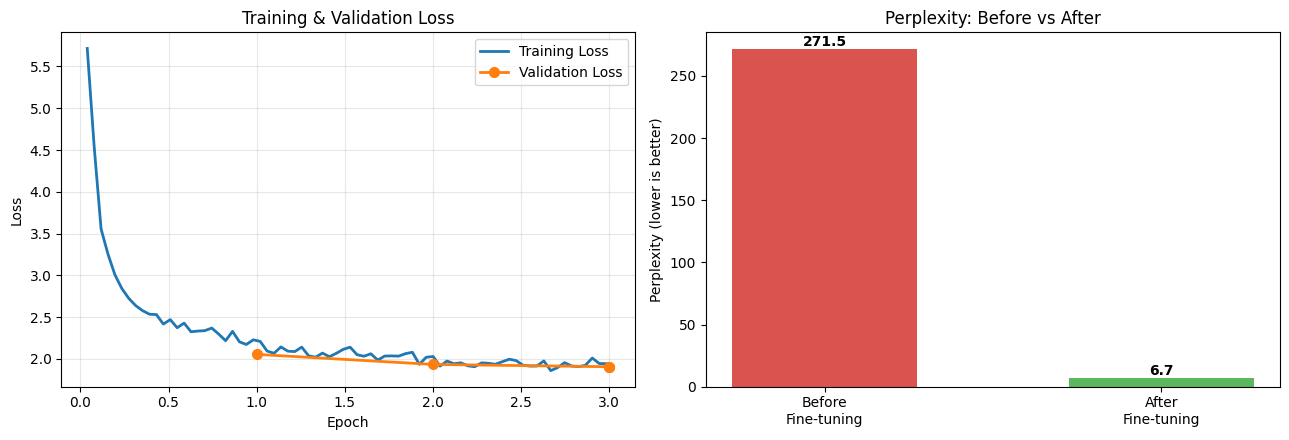

In [8]:
import matplotlib.pyplot as plt

hist = trainer.state.log_history
tr = [(h["epoch"], h["loss"])      for h in hist if "loss"      in h]
ev = [(h["epoch"], h["eval_loss"]) for h in hist if "eval_loss" in h]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(*zip(*tr), label="Training Loss", lw=2)
ax[0].plot(*zip(*ev), 'o-', label="Validation Loss", lw=2, ms=7)
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss")
ax[0].set_title("Training & Validation Loss")
ax[0].legend(); ax[0].grid(alpha=.3)

stages = ["Before\nFine-tuning", "After\nFine-tuning"]
ppls   = [math.exp(5.604), math.exp(metrics["eval_loss"])]
bars = ax[1].bar(stages, ppls, color=["#d9534f", "#5cb85c"], width=.55)
ax[1].set_ylabel("Perplexity (lower is better)")
ax[1].set_title("Perplexity: Before vs After")
for b, v in zip(bars, ppls):
    ax[1].text(b.get_x()+b.get_width()/2, v, f"{v:.1f}",
               ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig("results.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Training Dynamics

Validation loss tracks training loss closely across all three epochs, with no divergence —
the model is not overfitting. Validation loss was still decreasing at epoch 3, suggesting
additional epochs or more training dialogues would likely yield further gains.

## Conclusion

A DialoGPT-small model fine-tuned on 10,196 context-response pairs from MultiWOZ 2.2 produces
coherent, contextually grounded responses across multi-turn task-oriented conversations,
reducing perplexity from ~271 to 6.73.

**Key findings**

1. **Loss masking is what makes the model contextual.** Restricting the loss to response tokens
   is the difference between a model that replies and a model that imitates the conversation.

2. **Decoding strategy dominated output quality.** The same checkpoint produced degenerate text
   under sampling and clean, well-formed responses under beam search — a larger effect than any
   training hyperparameter.

3. **Library versions are part of the experiment.** A silent architectural change in
   `transformers` 5.0.0 — breaking GPT-2's weight tying — caused `NaN` divergence that looked
   like a data or hyperparameter bug. Pinned dependencies are a correctness requirement, not
   just a reproducibility nicety.

**Future work**

- Dialogue State Tracking over MultiWOZ's `frames` annotations, with database grounding
- Scaling to the full 8,437 dialogues and to `DialoGPT-medium`
- Human evaluation, which better reflects dialogue quality than single-reference BLEU